# Building AI Systems

- Pretraining language models on large corpus (base model)
- Finetuning on task (conversational model)
- Prompt for specific instance of task

# Base Models

In [1]:
from litellm import completion

In [2]:
def extract_answer(text: str) -> str:
    if "Q:" in text:
        return text.split("Q:")[0]
    if "\nQ:" in text:
        return text.split("\nQ:")[0]
    return text

In [3]:
def generate(prompt: str, length: int = 10, extract=False) -> str:
    response = completion(
        model="davinci-002",
        prompt=prompt,
        max_tokens=length,
        temperature=0,
    )

    text = response.choices[0].message.content

    if extract:
        return extract_answer(text)

    return text

The davinci-002 is similar to GPT-3 (175B)

### Language Models are Next Token Predictors

In [4]:
print(generate("the big brown fox"))

 jumps over the lazy dog" 
- How to


### Simple QA (Information Retrieval)

In [7]:
zero_shot_prompt = """Q: What is the capital of France?
A:"""
print(generate(zero_shot_prompt, length=100, extract=True))

 Paris




### Reasoning Task (Arithmetic Reasoning)

In [8]:
zero_shot_prompt = """Q: What is (2 + 2) * 4?
A:"""
print(generate(zero_shot_prompt, extract=True, length=10))

 8




# Few-shot Prompting (aka In-Context Learning)

*Language Models Are Few-Shot Learners (NIPS 2020)*

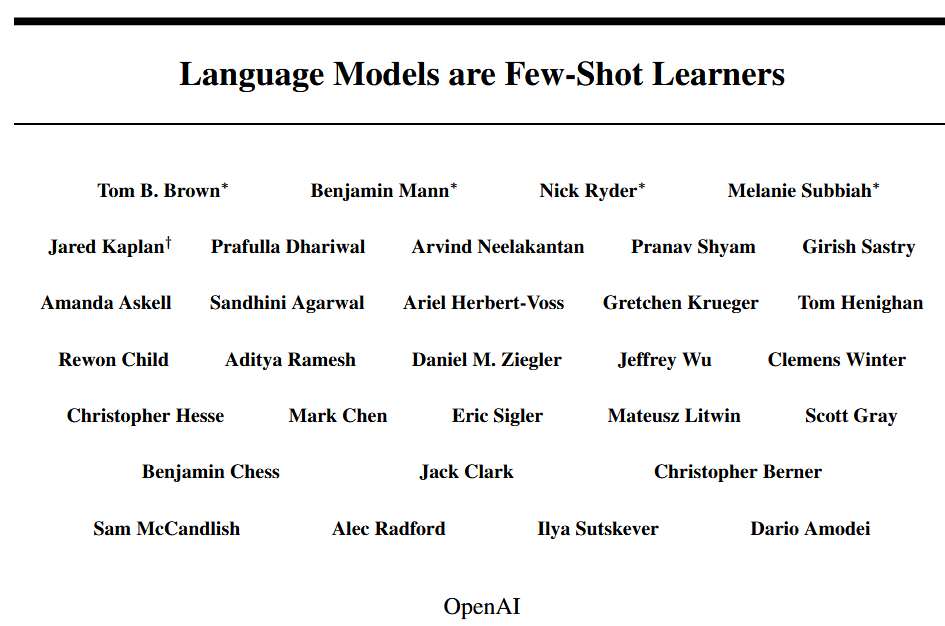

In [9]:
few_shot_prompt = """Q: What is 5 + 3?
A: 8
Q: What is 10 - 4?
A: 6
Q: What is (7 + 2) * 4?
A: 36
Q: What is (6 / 2) + 5?
A: 8
Q: What is (2 + 2) * 4?
A:"""

print(generate(few_shot_prompt, extract=True))

 16



# Chain-of-Thought

- Generate steps/reasoning + answer
- Shows better performance (Cobbe et al., 2021)

In [10]:
zero_shot_reason = """Q: What is (2 + 2) * 4?
A: Let's think step by step."""

print(generate(zero_shot_reason, extract=True, length=40))

 2 + 2 = 4. 4 * 4 = 16. 2 + 2 * 4 = 16.




## Zero-shot Reasoning

*Large Language Models are Zero-Shot Reasoners (NIPS 2022)*

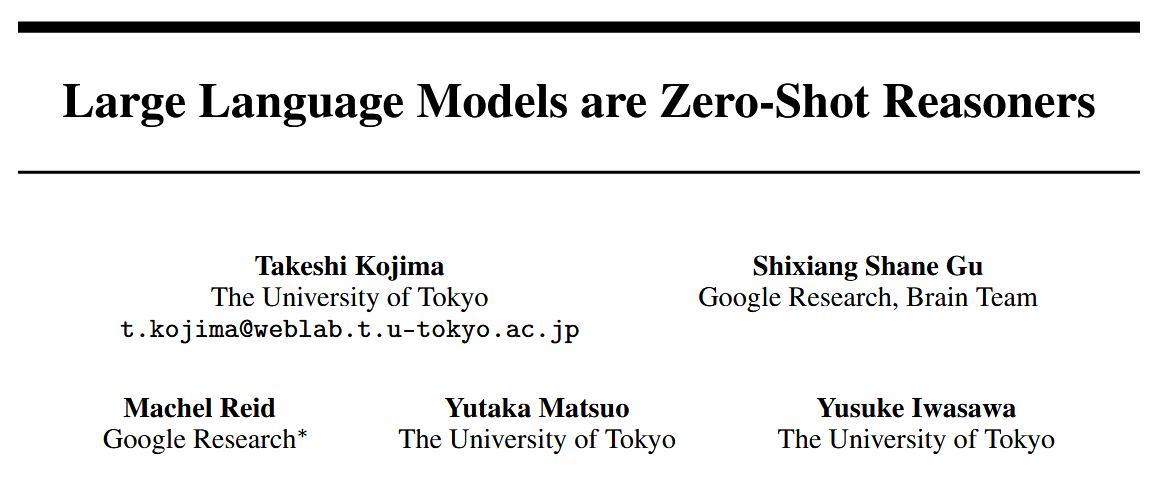

### Example (Math Word Problem)

In [11]:
zero_shot_reason = """Q: The cafeteria had 23 apples. If they used 20 to make lunch and bought 6 more, how many apples do they have?
A: Let's think step by step."""

print(generate(zero_shot_reason, extract=True, length=200))

 First, we need to find out how many apples they have. We know that they used 20 apples to make lunch. We also know that they bought 6 more apples. So, we can say that they have 20 + 6 = 26 apples. Now, we need to find out how many apples they had before they used 20 to make lunch. We know that they had 23 apples. So, we can say that they had 23 - 20 = 3 apples before they used 20 to make lunch. So, they had 26 - 3 = 23 apples before they used 20 to make lunch.




# What helps?

- Examples (to understand the task)
- Step-by-step generation (to break down reasoning) $\implies$ Chain of thought

# **Chain-of-thought Prompting (Today's Paper)**

*Chain-of-Thought Prompting Elicits Reasoning in Large Language Models (NIPS 2022)*

**Example 1**: One example, no CoT (GPT-3 Paper)

In [13]:
one_shot_prompt = """Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
A: The answer is 11
Q: The bookstore had 15 novels. They sold 7, then received a shipment of 10 more and someone donated 5. How many novels are in the bookstore now?
A: """

print(generate(one_shot_prompt, extract=True, length=150))

18



Should be 15 - 7 + 10 + 5 = 23

**Example 2**: One example, asked for CoT (Zero-shot reasoning paper)

In [14]:
zero_shot_reason = """Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
A: The answer is 11
Q: The bookstore had 15 novels. They sold 7, then received a shipment of 10 more and someone donated 5. How many novels are in the bookstore now?
A: Let's think step by step."""

print(generate(zero_shot_reason, extract=True, length=150))

 First, they sold 7. Then they received 10 more. Then someone donated 5. So, 7 + 10 + 5 = 22



**Example 3**: Single CoT Example (This paper)

In [ ]:
one_shot_cot_prompt = """Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
A: Roger started with 5 balls. 2 cans of 3 tennis balls each is 6 tennis balls. 5 + 6 = 15. The answer is 15
Q: The bookstore had 15 novels. They sold 7, then received a shipment of 10 more and someone donated 5. How many novels are in the bookstore now?
A: """

print(generate(one_shot_cot_prompt, extract=True, length=150))

15 - 7 = 8. 8 + 10 = 18. 18 + 5 = 23. The answer is 23



**Example 4**: Few CoT Example (This paper)

In [16]:
few_shot_cot_prompt = """Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
A: Roger started with 5 balls. 2 cans of 3 tennis balls each is 6 tennis balls. 5 + 6 = 11. The answer is 11
Q: Sarah has 10 cookies. She gives 4 to her friend and then bakes 8 more. She ate 3 herself. How many cookies does she have now?
A: Sarah started with 10 cookies. She gave away 4, so she had 10 - 4 = 6 left. She baked 8 more, so now she has 6 + 8 = 14 cookies. She ate 3, so she has 14 - 3 = 11 cookies left. The answer is 11.
Q: The bookstore had 15 novels. They sold 7, then received a shipment of 10 more and someone donated 5. How many novels are in the bookstore now?
A: """

print(generate(few_shot_cot_prompt, extract=True, length=150))

15 - 7 = 8. 10 + 5 = 15. 8 + 15 = 23. The answer is 23.



### CoT prompting may fail

**Example 5**: Adding a weak example without showing calculations in the reasoning steps

In [18]:
few_shot_cot_prompt = """Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
A: Roger started with 5 balls. 2 cans of 3 tennis balls each is 6 tennis balls. 5 + 6 = 11. The answer is 11
Q: Sarah has 10 cookies. She gives 4 to her friend and then bakes 8 more. How many cookies does she have now?
A: Sarah started with 10 cookies. She gave away 4, leaving her with 6 cookies. She then baked 8 more, so 14. The answer is 14
Q: The bookstore had 15 novels. They sold 7, then received a shipment of 10 more and someone donated 5. How many novels are in the bookstore now?
A: """

print(generate(few_shot_cot_prompt, extract=True, length=150))

15 - 7 = 8. 10 + 5 = 15. The answer is 15



# **Self-Consistency**

*Self-Consistency Improves Chain of Thought Reasoning in Language Models (ICLR 2023)*

### Idea of Self-consistency

- Raise temperature
- Sample multiple times
- Choose a "consistent" answer (e.g. most frequent)

In [19]:
def generate_samples(prompt: str, length: int = 10, extract: bool = False, t: float = 1, k: int = 1) -> list:
    texts = []

    for i in range(k):
        response = completion(
            model="davinci-002",
            prompt=prompt,
            max_tokens=length,
            temperature=t,
        )

        text = response.choices[0].message.content

        if extract:
            text = extract_answer(text)

        texts.append(text)

        print(f"Sample {i+1}:\n{text}\n{'-'*20}")
    return texts

In [20]:
texts = generate_samples(few_shot_cot_prompt, extract=True, length=150, t=0.5, k=10)

Sample 1:
15 novels were in the bookstore at the beginning. 7 were sold, so 15 - 7 = 8. 10 were received, so 8 + 10 = 18. 5 were donated, so 18 + 5 = 23. The answer is 23

--------------------
Sample 2:
15 - 7 = 8. 8 + 10 = 18. 18 + 5 = 23. The answer is 23

--------------------
Sample 3:
15 - 7 = 8; 10 + 5 = 15; 15 + 8 = 23. The answer is 23

--------------------
Sample 4:
15 - 7 = 8. 10 + 5 = 15. The answer is 15

--------------------
Sample 5:
15 - 7 = 8, 10 + 5 = 15, so 8 + 15 = 23. The answer is 23.

--------------------
Sample 6:
15 - 7 = 8 10 + 5 = 15 8 + 15 = 23. The answer is 23


--------------------
Sample 7:
15 - 7 = 8, 10 + 5 = 15. The answer is 15

--------------------
Sample 8:
15 novels - 7 = 8 novels. 10 novels + 5 novels = 15 novels. The answer is 15


--------------------
Sample 9:
15 - 7 + 10 + 5 = 23

--------------------
Sample 10:
15 - 7 = 8, 8 + 10 = 18, 18 + 5 = 23. The answer is 23

--------------------
